In [ ]:
!pip install cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 55.5 MB/s eta 0:00:00


HTH MÉXICO 2026 - PREDICCIÓN PROBABILÍSTICA
Archivo de aristas: grafo_aristas.csv
Archivo de nodos: nodos.csv
Transiciones condicionadas: 24
Matriz condicionada: (11, 15)
Nodos en grafo: 17
Aristas en grafo: 24
Nodos iniciales posibles: 11
Trayectorias simuladas: 10000
Rasterización: 1000 / 10000 simulaciones
Rasterización: 2000 / 10000 simulaciones
Rasterización: 3000 / 10000 simulaciones
Rasterización: 4000 / 10000 simulaciones
Rasterización: 5000 / 10000 simulaciones
Rasterización: 6000 / 10000 simulaciones
Rasterización: 7000 / 10000 simulaciones
Rasterización: 8000 / 10000 simulaciones
Rasterización: 9000 / 10000 simulaciones
Rasterización: 10000 / 10000 simulaciones
Celdas del mapa: 64128
Celdas no cero: 16780
Probabilidad máxima visual: 1.0


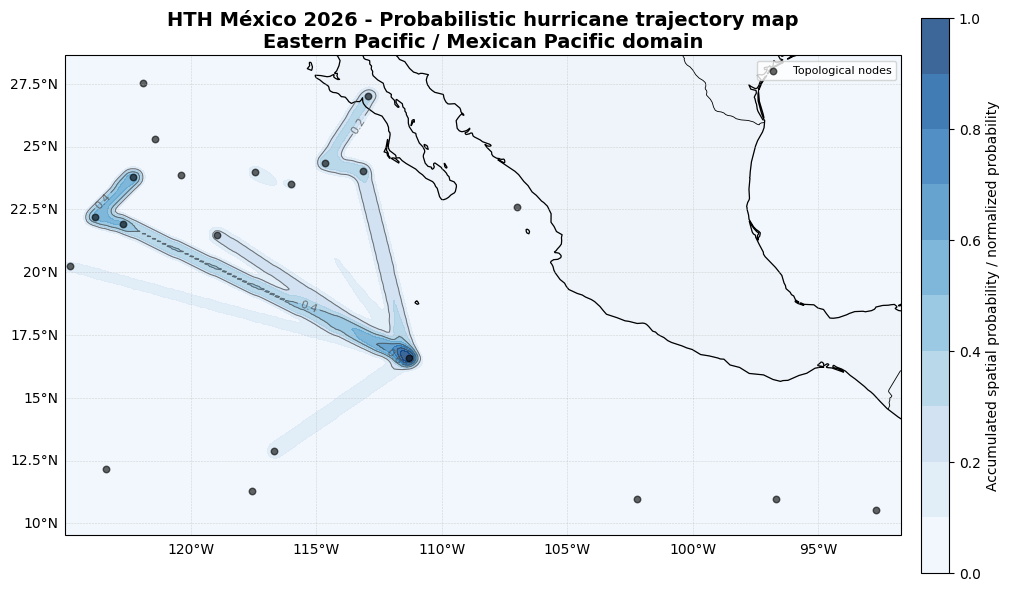

Mapa guardado: prediccion_hth_2026/mapa_probabilistico_trayectoria_2026_pacifico.png


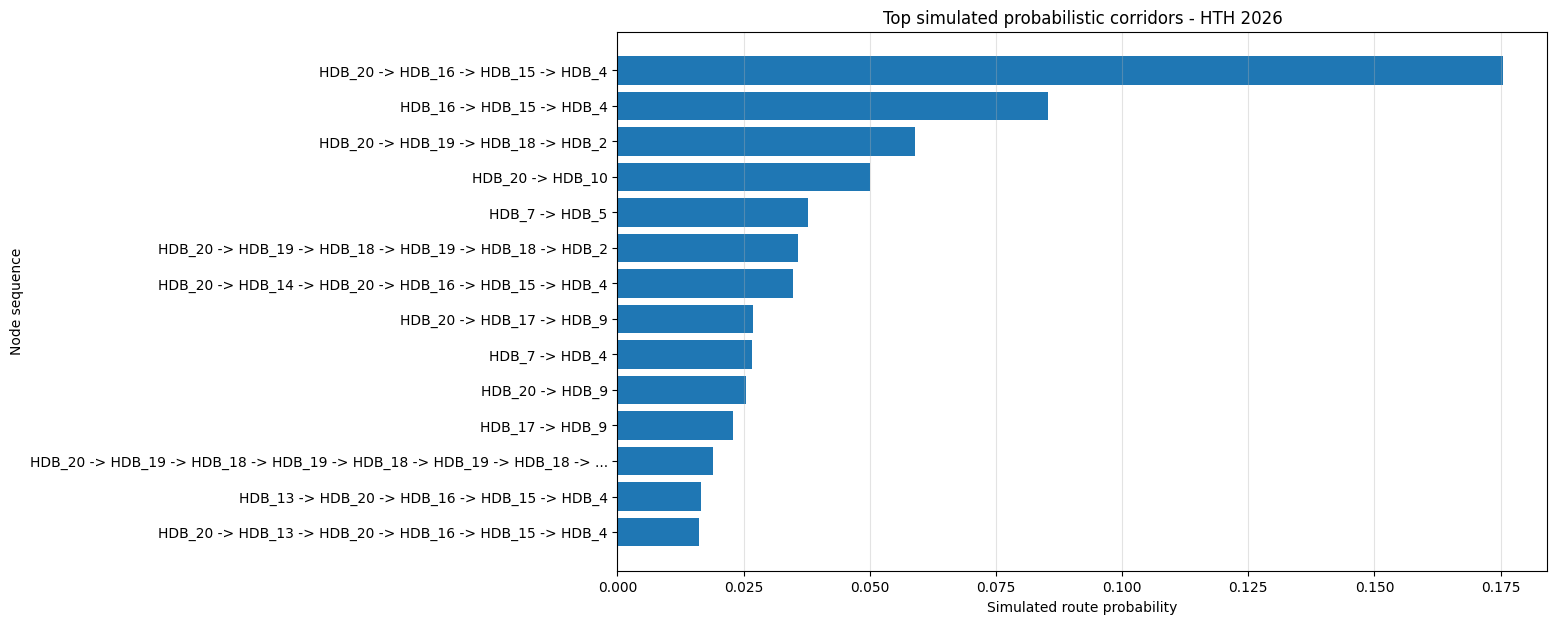

Ranking guardado: prediccion_hth_2026/ranking_corredores_2026.png
PRODUCTOS GENERADOS
- prediccion_hth_2026/mapa_probabilistico_trayectoria_2026_pacifico.csv
- prediccion_hth_2026/mapa_probabilistico_trayectoria_2026_pacifico.png
- prediccion_hth_2026/mapa_probabilistico_trayectoria_2026_pacifico_no_cero.csv
- prediccion_hth_2026/metadatos_prediccion_2026.json
- prediccion_hth_2026/pgm_matriz_transicion_condicionada.csv
- prediccion_hth_2026/pgm_matriz_transicion_condicionada_larga.csv
- prediccion_hth_2026/pgm_trayectorias_simuladas.csv
- prediccion_hth_2026/prediccion_aristas_2026.csv
- prediccion_hth_2026/prediccion_corredores_2026.csv
- prediccion_hth_2026/prediccion_nodos_2026.csv
- prediccion_hth_2026/ranking_corredores_2026.png
- prediccion_hth_2026/resumen_prediccion_2026.csv
- prediccion_hth_2026/rutas_mas_probables_dijkstra_2026.csv
- prediccion_hth_2026/trayectorias_simuladas_2026_muestra.csv

ZIP generado: prediccion_hth_2026_productos.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# ============================================================
# HTH MÉXICO 2026
# Predicción probabilística de trayectorias ciclónicas
# Pacífico mexicano
#
# Genera:
# - Mapa probabilístico lat-lon-probabilidad
# - Mapa con contornos tipo superficie probabilística
# - Simulación Monte Carlo de trayectorias sobre grafo
# - Ranking de corredores/aristas/nodos
# - Metadatos de trazabilidad al 31 de mayo de 2026
# ============================================================

import os
import re
import json
import math
import zipfile
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

from scipy.ndimage import gaussian_filter

warnings.filterwarnings("ignore")

# ============================================================
# 1. CONFIGURACIÓN GENERAL
# ============================================================

FECHA_EMISION = "2026-05-31"
HORIZONTE_PRONOSTICO = "Temporada ciclónica 2026 del Pacífico mexicano"
NOMBRE_MODELO = "Modelo gráfico probabilístico topológico-estacional HTH 2026"

# Archivos de entrada
ARCHIVO_ARISTAS_CANDIDATOS = [
    "grafo_aristas.csv",
    "grafo_aristas_modelo.csv",
    "aristas_topologicas.csv",
    "data/grafo_aristas.csv"
]

ARCHIVO_NODOS_CANDIDATOS = [
    "nodos.csv",
    "nodos_modelo.csv",
    "nodos_topologicos.csv",
    "data/nodos.csv"
]

ARCHIVO_TRACKS_CANDIDATOS = [
    "huracanes_pacifico_recortado.xlsx",
    "huracanes_pacifico_recortado.csv",
    "huracanes_pacifico_variables_extremas.csv",
    "tracks_pacifico.csv"
]

# Salidas
CARPETA_SALIDA = Path("prediccion_hth_2026")
CARPETA_SALIDA.mkdir(exist_ok=True)

# Columnas esperadas
COL_ORIGEN = "node_origen"
COL_DESTINO = "node_destino"
COL_FRECUENCIA = "frecuencia_transicion"
COL_PROB = "probabilidad_transicion"

# Parámetros del modelo
N_SIMULACIONES = 10000
HORIZONTE_PASOS = 8
START_NODE = None

# Si quieres forzar nodo inicial:
# START_NODE = "HDB_20"

# Temporada del Pacífico: junio-noviembre
# Pesos climatológicos aproximados derivados de concentración mensual histórica
PESOS_MESES_TEMPORADA = {
    6: 0.062,
    7: 0.226,
    8: 0.253,
    9: 0.281,
    10: 0.164,
    11: 0.014
}

# Evidencia continua opcional
# Puedes activar condiciones si tus aristas tienen esas columnas.
EVIDENCIA_CONTINUA = {
    # "distancia_tierra": {
    #     "col": "cem_distancia_tierra_km_media_arista",
    #     "value": 250.0,
    #     "sigma": 150.0
    # },
    # "orografia_250": {
    #     "col": "cem_interaccion_orografica_250km_media_arista",
    #     "value": 0.30,
    #     "sigma": 0.20
    # },
    # "sst": {
    #     "col": "era5_sst_c_media_arista",
    #     "value": 29.0,
    #     "sigma": 1.5
    # }
}

# Mapa probabilístico
RESOLUCION_GRADOS = 0.10
CORREDOR_KM = 35.0
BUFFER_GRADOS = 1.0
SIGMA_SUAVIZADO = 1.25

# Dominio Pacífico mexicano
LON_MIN_DEFAULT = -125
LON_MAX_DEFAULT = -88
LAT_MIN_DEFAULT = 6.0
LAT_MAX_DEFAULT = 34.5

# Tracks históricos opcionales para superponer en el mapa
TRACKS_ANALOGOS = [
    {
        "name": "PAULINE",
        "year": 1997,
        "color": "black",
        "label": "Hurricane track: Pauline October 1997"
    },
    {
        "name": "OTIS",
        "year": 2023,
        "color": "red",
        "label": "Hurricane track: Otis October 2023"
    }
]

SEED = 42
np.random.seed(SEED)


# ============================================================
# 2. FUNCIONES AUXILIARES
# ============================================================

def buscar_archivo(candidatos):
    for archivo in candidatos:
        path = Path(archivo)
        if path.exists():
            return path
    return None


def normalizar_vector(x):
    x = np.asarray(x, dtype=float)
    x = np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
    x[x < 0] = 0

    suma = x.sum()

    if suma <= 0:
        return np.ones_like(x) / len(x)

    return x / suma


def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371.0

    lat1 = np.radians(lat1)
    lon1 = np.radians(lon1)
    lat2 = np.radians(lat2)
    lon2 = np.radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1) * np.cos(lat2) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arcsin(np.sqrt(a))

    return R * c


def parsear_meses(texto):
    if pd.isna(texto):
        return {}

    texto = str(texto)
    pares = re.findall(r"(\d+)\s*\((\d+)\)", texto)

    conteos = {}

    for mes, conteo in pares:
        mes = int(mes)
        conteo = int(conteo)
        conteos[mes] = conteos.get(mes, 0) + conteo

    return conteos


def score_mes(row, mes_objetivo, alpha=0.5):
    if "meses_donde_ocurre" not in row.index:
        return 1.0

    conteos = parsear_meses(row["meses_donde_ocurre"])

    if len(conteos) == 0:
        return 1.0

    total = sum(conteos.values())

    return (conteos.get(mes_objetivo, 0) + alpha) / (total + 12.0 * alpha)


def score_temporada(row, pesos_meses):
    score = 0.0

    for mes, peso in pesos_meses.items():
        score += peso * score_mes(row, mes)

    if score <= 0 or pd.isna(score):
        return 1.0

    return score


def score_gaussiano(valor, objetivo, sigma):
    if pd.isna(valor):
        return 1.0

    if sigma <= 0:
        return 1.0

    z = (float(valor) - float(objetivo)) / float(sigma)

    return math.exp(-0.5 * z * z)


def score_evidencia_continua(row, evidencia_continua):
    score = 1.0

    for nombre, cfg in evidencia_continua.items():
        if not isinstance(cfg, dict):
            continue

        col = cfg.get("col")
        value = cfg.get("value")
        sigma = cfg.get("sigma")

        if col is None or value is None or sigma is None:
            continue

        if col not in row.index:
            continue

        score *= score_gaussiano(row[col], value, sigma)

    return score


def leer_aristas(path):
    df = pd.read_csv(path)

    rename = {}

    if "origen" in df.columns and COL_ORIGEN not in df.columns:
        rename["origen"] = COL_ORIGEN

    if "destino" in df.columns and COL_DESTINO not in df.columns:
        rename["destino"] = COL_DESTINO

    if "source" in df.columns and COL_ORIGEN not in df.columns:
        rename["source"] = COL_ORIGEN

    if "target" in df.columns and COL_DESTINO not in df.columns:
        rename["target"] = COL_DESTINO

    df = df.rename(columns=rename)

    for col in [COL_ORIGEN, COL_DESTINO]:
        if col not in df.columns:
            raise ValueError(f"Falta columna requerida en aristas: {col}")

    df[COL_ORIGEN] = df[COL_ORIGEN].astype(str)
    df[COL_DESTINO] = df[COL_DESTINO].astype(str)

    if COL_FRECUENCIA not in df.columns:
        df[COL_FRECUENCIA] = 1.0

    df[COL_FRECUENCIA] = pd.to_numeric(
        df[COL_FRECUENCIA],
        errors="coerce"
    ).fillna(0)

    if COL_PROB not in df.columns:
        salidas = (
            df.groupby(COL_ORIGEN)[COL_FRECUENCIA]
            .sum()
            .reset_index(name="total_salidas")
        )

        df = df.merge(salidas, on=COL_ORIGEN, how="left")

        df[COL_PROB] = np.where(
            df["total_salidas"] > 0,
            df[COL_FRECUENCIA] / df["total_salidas"],
            0
        )

    df[COL_PROB] = pd.to_numeric(
        df[COL_PROB],
        errors="coerce"
    ).fillna(0)

    return df


def leer_nodos(path, nodos_requeridos):
    nodos = pd.read_csv(path)

    rename = {}

    # ID
    if "id" in nodos.columns and "node_id" not in nodos.columns:
        rename["id"] = "node_id"

    # Latitud
    for c in ["lat", "latitude", "latitud", "lat_centro"]:
        if c in nodos.columns:
            rename[c] = "latitud"
            break

    # Longitud
    for c in ["lon", "longitude", "longitud", "lon_centro"]:
        if c in nodos.columns:
            rename[c] = "longitud"
            break

    nodos = nodos.rename(columns=rename)

    columnas_req = ["node_id", "latitud", "longitud"]

    for col in columnas_req:
        if col not in nodos.columns:
            raise ValueError(
                f"El archivo de nodos debe contener {col}. "
                "Usa columnas node_id, latitud y longitud, "
                "o lat_centro/lon_centro."
            )

    nodos["node_id"] = nodos["node_id"].astype(str)
    nodos["latitud"] = pd.to_numeric(nodos["latitud"], errors="coerce")
    nodos["longitud"] = pd.to_numeric(nodos["longitud"], errors="coerce")

    nodos = nodos.dropna(subset=["node_id", "latitud", "longitud"]).copy()

    nodos_en_archivo = set(nodos["node_id"])
    faltantes = sorted(set(nodos_requeridos) - nodos_en_archivo)

    if len(faltantes) > 0:
        print("Advertencia: faltan nodos en archivo de nodos:", faltantes)

    return nodos


def cargar_tracks_opcionales():
    path = buscar_archivo(ARCHIVO_TRACKS_CANDIDATOS)

    if path is None:
        return None

    try:
        if path.suffix.lower() in [".xlsx", ".xls"]:
            tracks = pd.read_excel(path)
        else:
            tracks = pd.read_csv(path)

        if "datetime" in tracks.columns:
            tracks["datetime"] = pd.to_datetime(
                tracks["datetime"],
                errors="coerce",
                utc=True
            )

        if "name" in tracks.columns:
            tracks["name"] = tracks["name"].astype(str).str.upper()

        if "year" not in tracks.columns and "datetime" in tracks.columns:
            tracks["year"] = tracks["datetime"].dt.year

        if not all(c in tracks.columns for c in ["lat", "lon"]):
            return None

        print("Tracks opcionales cargados desde:", path)
        return tracks

    except Exception as e:
        print("No se pudieron cargar tracks opcionales:", e)
        return None


# ============================================================
# 3. TRANSICIONES CONDICIONADAS
# ============================================================

def construir_transiciones_condicionadas(
    df_aristas,
    pesos_meses,
    evidencia_continua
):
    df = df_aristas.copy()

    scores_temp = []
    scores_cont = []

    for _, row in df.iterrows():
        scores_temp.append(score_temporada(row, pesos_meses))
        scores_cont.append(score_evidencia_continua(row, evidencia_continua))

    df["score_temporada"] = scores_temp
    df["score_evidencia_continua"] = scores_cont

    df["peso_no_normalizado"] = (
        df[COL_PROB]
        * df["score_temporada"]
        * df["score_evidencia_continua"]
    )

    df["probabilidad_condicionada"] = np.nan

    for origen, grupo in df.groupby(COL_ORIGEN):
        pesos = grupo["peso_no_normalizado"].values

        if np.nansum(pesos) <= 0:
            pesos = grupo[COL_PROB].values

        probs = normalizar_vector(pesos)

        df.loc[grupo.index, "probabilidad_condicionada"] = probs

    matriz = df.pivot_table(
        index=COL_ORIGEN,
        columns=COL_DESTINO,
        values="probabilidad_condicionada",
        aggfunc="sum",
        fill_value=0
    )

    return df, matriz


def construir_grafo(df_transiciones):
    G = nx.DiGraph()

    for _, row in df_transiciones.iterrows():
        origen = row[COL_ORIGEN]
        destino = row[COL_DESTINO]

        attrs = row.dropna().to_dict()

        p = float(row["probabilidad_condicionada"])

        attrs["weight"] = p
        attrs["costo_probabilistico_condicionado"] = (
            -np.log(p) if p > 0 else np.inf
        )

        G.add_edge(origen, destino, **attrs)

    return G


def construir_salidas(df_transiciones):
    salidas = {}

    for origen, grupo in df_transiciones.groupby(COL_ORIGEN):
        destinos = grupo[COL_DESTINO].astype(str).tolist()
        probs = grupo["probabilidad_condicionada"].values.astype(float)
        probs = normalizar_vector(probs)

        salidas[origen] = {
            "destinos": destinos,
            "probs": probs
        }

    return salidas


def distribucion_inicial(df_transiciones, start_node=None):
    if start_node is not None:
        return [start_node], np.array([1.0])

    frec = (
        df_transiciones
        .groupby(COL_ORIGEN)[COL_FRECUENCIA]
        .sum()
        .sort_values(ascending=False)
    )

    nodos = frec.index.astype(str).tolist()
    probs = normalizar_vector(frec.values)

    return nodos, probs


# ============================================================
# 4. SIMULACIÓN MONTE CARLO
# ============================================================

def simular_trayectorias(
    salidas,
    nodos_iniciales,
    probs_iniciales,
    n_simulaciones,
    horizonte_pasos,
    seed=42
):
    rng = np.random.default_rng(seed)

    trayectorias = []

    for sim in range(n_simulaciones):
        actual = rng.choice(nodos_iniciales, p=probs_iniciales)

        nodos = [actual]
        aristas = []
        prob_tray = 1.0

        for paso in range(horizonte_pasos):
            if actual not in salidas:
                break

            destinos = salidas[actual]["destinos"]
            probs = salidas[actual]["probs"]

            if len(destinos) == 0:
                break

            idx = rng.choice(len(destinos), p=probs)

            siguiente = destinos[idx]
            p = probs[idx]

            aristas.append((actual, siguiente))
            nodos.append(siguiente)

            prob_tray *= p
            actual = siguiente

        trayectorias.append({
            "id_simulacion": sim,
            "secuencia_nodos_lista": nodos,
            "secuencia_aristas_lista": aristas,
            "longitud_pasos": len(aristas),
            "probabilidad_trayectoria": prob_tray
        })

    return trayectorias


def trayectorias_a_dataframe(trayectorias):
    filas = []

    for tr in trayectorias:
        filas.append({
            "id_simulacion": tr["id_simulacion"],
            "longitud_pasos": tr["longitud_pasos"],
            "probabilidad_trayectoria": tr["probabilidad_trayectoria"],
            "secuencia_nodos": " -> ".join(tr["secuencia_nodos_lista"]),
            "secuencia_aristas": " | ".join(
                [f"{u}->{v}" for u, v in tr["secuencia_aristas_lista"]]
            )
        })

    return pd.DataFrame(filas)


def resumen_nodos_simulados(trayectorias):
    filas = []

    for tr in trayectorias:
        nodos_unicos = set(tr["secuencia_nodos_lista"])

        for nodo in nodos_unicos:
            filas.append({
                "id_simulacion": tr["id_simulacion"],
                "node_id": nodo
            })

    df = pd.DataFrame(filas)

    resumen = (
        df.groupby("node_id")
        .agg(simulaciones_con_visita=("id_simulacion", "nunique"))
        .reset_index()
    )

    resumen["probabilidad_visita"] = (
        resumen["simulaciones_con_visita"] / len(trayectorias)
    )

    return resumen.sort_values("probabilidad_visita", ascending=False)


def resumen_aristas_simuladas(trayectorias):
    filas = []

    for tr in trayectorias:
        aristas_unicas = set(tr["secuencia_aristas_lista"])

        for u, v in aristas_unicas:
            filas.append({
                "id_simulacion": tr["id_simulacion"],
                "node_origen": u,
                "node_destino": v,
                "edge_id": f"{u}->{v}"
            })

    df = pd.DataFrame(filas)

    resumen = (
        df.groupby(["node_origen", "node_destino", "edge_id"])
        .agg(simulaciones_con_uso=("id_simulacion", "nunique"))
        .reset_index()
    )

    resumen["probabilidad_uso"] = (
        resumen["simulaciones_con_uso"] / len(trayectorias)
    )

    return resumen.sort_values("probabilidad_uso", ascending=False)


def resumen_corredores_simulados(trayectorias):
    df = trayectorias_a_dataframe(trayectorias)

    resumen = (
        df.groupby("secuencia_nodos")
        .agg(
            frecuencia=("id_simulacion", "count"),
            probabilidad_media_trayectoria=("probabilidad_trayectoria", "mean"),
            longitud_media=("longitud_pasos", "mean")
        )
        .reset_index()
    )

    resumen["probabilidad_simulada"] = resumen["frecuencia"] / len(trayectorias)

    resumen = resumen.sort_values(
        ["probabilidad_simulada", "probabilidad_media_trayectoria"],
        ascending=False
    )

    return resumen


# ============================================================
# 5. RUTAS MÁS PROBABLES CON DIJKSTRA
# ============================================================

def calcular_rutas_dijkstra(G, start_node=None):
    if start_node is None:
        if len(G.nodes) == 0:
            return pd.DataFrame()

        start_node = max(
            G.out_degree(weight="weight"),
            key=lambda x: x[1]
        )[0]

    filas = []

    for destino in G.nodes:
        if destino == start_node:
            continue

        try:
            ruta = nx.shortest_path(
                G,
                source=start_node,
                target=destino,
                weight="costo_probabilistico_condicionado"
            )

            costo = nx.shortest_path_length(
                G,
                source=start_node,
                target=destino,
                weight="costo_probabilistico_condicionado"
            )

            prob_aprox = np.exp(-costo)

            filas.append({
                "node_origen": start_node,
                "node_destino": destino,
                "ruta": " -> ".join(ruta),
                "costo_probabilistico": costo,
                "probabilidad_aproximada": prob_aprox,
                "longitud_nodos": len(ruta)
            })

        except:
            continue

    if len(filas) == 0:
        return pd.DataFrame()

    return (
        pd.DataFrame(filas)
        .sort_values("probabilidad_aproximada", ascending=False)
        .reset_index(drop=True)
    )


# ============================================================
# 6. RASTERIZACIÓN DEL MAPA PROBABILÍSTICO
# ============================================================

def interpolar_segmento(lat1, lon1, lat2, lon2, resolucion_km=10.0):
    dist = haversine_km(lat1, lon1, lat2, lon2)

    n = max(2, int(np.ceil(dist / resolucion_km)))

    lats = np.linspace(lat1, lat2, n)
    lons = np.linspace(lon1, lon2, n)

    return lats, lons


def rasterizar_trayectorias(
    trayectorias,
    nodos,
    resolucion_grados=0.10,
    corredor_km=35.0,
    buffer_grados=1.0
):
    node_pos = {
        row["node_id"]: (row["latitud"], row["longitud"])
        for _, row in nodos.iterrows()
    }

    lat_min = max(
        LAT_MIN_DEFAULT,
        nodos["latitud"].min() - buffer_grados
    )

    lat_max = min(
        LAT_MAX_DEFAULT,
        nodos["latitud"].max() + buffer_grados
    )

    lon_min = max(
        LON_MIN_DEFAULT,
        nodos["longitud"].min() - buffer_grados
    )

    lon_max = min(
        LON_MAX_DEFAULT,
        nodos["longitud"].max() + buffer_grados
    )

    lat_values = np.arange(lat_min, lat_max + resolucion_grados, resolucion_grados)
    lon_values = np.arange(lon_min, lon_max + resolucion_grados, resolucion_grados)

    hits = np.zeros((len(lat_values), len(lon_values)), dtype=float)

    for idx_sim, tr in enumerate(trayectorias):
        celdas_visitadas = set()

        aristas = tr["secuencia_aristas_lista"]

        for u, v in aristas:
            if u not in node_pos or v not in node_pos:
                continue

            lat1, lon1 = node_pos[u]
            lat2, lon2 = node_pos[v]

            lats_seg, lons_seg = interpolar_segmento(
                lat1,
                lon1,
                lat2,
                lon2,
                resolucion_km=10.0
            )

            for latp, lonp in zip(lats_seg, lons_seg):
                lat_radius_deg = corredor_km / 111.0

                cos_lat = max(
                    0.2,
                    abs(np.cos(np.radians(latp)))
                )

                lon_radius_deg = corredor_km / (111.0 * cos_lat)

                i_min = max(
                    0,
                    np.searchsorted(lat_values, latp - lat_radius_deg) - 1
                )

                i_max = min(
                    len(lat_values) - 1,
                    np.searchsorted(lat_values, latp + lat_radius_deg) + 1
                )

                j_min = max(
                    0,
                    np.searchsorted(lon_values, lonp - lon_radius_deg) - 1
                )

                j_max = min(
                    len(lon_values) - 1,
                    np.searchsorted(lon_values, lonp + lon_radius_deg) + 1
                )

                for i in range(i_min, i_max + 1):
                    for j in range(j_min, j_max + 1):
                        d = haversine_km(
                            latp,
                            lonp,
                            lat_values[i],
                            lon_values[j]
                        )

                        if d <= corredor_km:
                            celdas_visitadas.add((i, j))

        for i, j in celdas_visitadas:
            hits[i, j] += 1

        if (idx_sim + 1) % 1000 == 0:
            print(f"Rasterización: {idx_sim + 1} / {len(trayectorias)} simulaciones")

    prob_raw = hits / len(trayectorias)

    return lat_values, lon_values, prob_raw


def mapa_a_dataframe(lat_values, lon_values, prob_raw, sigma_suavizado=1.25):
    prob_smooth = gaussian_filter(prob_raw, sigma=sigma_suavizado)

    if np.nanmax(prob_smooth) > 0:
        prob_visual_norm = prob_smooth / np.nanmax(prob_smooth)
    else:
        prob_visual_norm = prob_smooth

    filas = []

    for i, lat in enumerate(lat_values):
        for j, lon in enumerate(lon_values):
            filas.append({
                "lat": lat,
                "lon": lon,
                "probabilidad_paso_raw": prob_raw[i, j],
                "probabilidad_visual_suavizada": prob_smooth[i, j],
                "probabilidad": prob_visual_norm[i, j]
            })

    df = pd.DataFrame(filas)

    return df, prob_smooth, prob_visual_norm


# ============================================================
# 7. VISUALIZACIÓN CARTOGRÁFICA
# ============================================================

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    CARTOPY_OK = True
except:
    CARTOPY_OK = False
    print("Cartopy no disponible. Se graficará con ejes lon-lat simples.")


def crear_mapa_base(ax, lon_min, lon_max, lat_min, lat_max):
    if CARTOPY_OK:
        ax.set_extent([lon_min, lon_max, lat_min, lat_max], crs=ccrs.PlateCarree())

        ax.add_feature(
            cfeature.OCEAN,
            facecolor="white"
        )

        ax.add_feature(
            cfeature.LAND,
            facecolor="#f2f2f2",
            edgecolor="gray",
            linewidth=0.6
        )

        ax.add_feature(cfeature.COASTLINE, linewidth=0.9)
        ax.add_feature(cfeature.BORDERS, linewidth=0.6)

        try:
            states = cfeature.NaturalEarthFeature(
                category="cultural",
                name="admin_1_states_provinces_lines",
                scale="50m",
                facecolor="none"
            )

            ax.add_feature(
                states,
                edgecolor="gray",
                linewidth=0.35
            )
        except:
            pass

        gl = ax.gridlines(
            draw_labels=True,
            linewidth=0.4,
            alpha=0.5,
            linestyle="--"
        )

        gl.top_labels = False
        gl.right_labels = False

    else:
        ax.set_xlim(lon_min, lon_max)
        ax.set_ylim(lat_min, lat_max)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
        ax.grid(True, alpha=0.35)


def plot_tracks_analogos(ax, tracks):
    if tracks is None:
        return

    if not all(c in tracks.columns for c in ["name", "year", "lat", "lon"]):
        return

    for cfg in TRACKS_ANALOGOS:
        nombre = cfg["name"].upper()
        year = cfg["year"]
        color = cfg["color"]
        label = cfg["label"]

        sub = tracks[
            (tracks["name"].astype(str).str.upper() == nombre) &
            (tracks["year"] == year)
        ].copy()

        if len(sub) == 0:
            continue

        if "datetime" in sub.columns:
            sub = sub.sort_values("datetime")

        kwargs = {}

        if CARTOPY_OK:
            kwargs["transform"] = ccrs.PlateCarree()

        ax.plot(
            sub["lon"],
            sub["lat"],
            color=color,
            linewidth=1.8,
            marker="o",
            markersize=3.0,
            label=label,
            **kwargs
        )


def graficar_mapa_probabilistico(
    lat_values,
    lon_values,
    prob_visual,
    nodos,
    tracks=None
):
    Lon, Lat = np.meshgrid(lon_values, lat_values)

    lon_min = lon_values.min()
    lon_max = lon_values.max()
    lat_min = lat_values.min()
    lat_max = lat_values.max()

    if CARTOPY_OK:
        fig = plt.figure(figsize=(13, 8))
        ax = plt.axes(projection=ccrs.PlateCarree())
    else:
        fig, ax = plt.subplots(figsize=(13, 8))

    crear_mapa_base(ax, lon_min, lon_max, lat_min, lat_max)

    levels = np.linspace(0, 1, 11)

    contour_kwargs = {}

    if CARTOPY_OK:
        contour_kwargs["transform"] = ccrs.PlateCarree()

    cf = ax.contourf(
        Lon,
        Lat,
        prob_visual,
        levels=levels,
        cmap="Blues",
        alpha=0.78,
        **contour_kwargs
    )

    line_levels = [0.2, 0.4, 0.6, 0.8]

    cs = ax.contour(
        Lon,
        Lat,
        prob_visual,
        levels=line_levels,
        colors="#4d4d4d",
        linewidths=0.75,
        alpha=0.75,
        **contour_kwargs
    )

    ax.clabel(
        cs,
        inline=True,
        fontsize=8,
        fmt="%.1f"
    )

    # Nodos
    scatter_kwargs = {}
    if CARTOPY_OK:
        scatter_kwargs["transform"] = ccrs.PlateCarree()

    ax.scatter(
        nodos["longitud"],
        nodos["latitud"],
        s=22,
        color="black",
        alpha=0.60,
        label="Topological nodes",
        **scatter_kwargs
    )

    # Tracks análogos opcionales
    plot_tracks_analogos(ax, tracks)

    if CARTOPY_OK:
        ax.set_title(
            "HTH México 2026 - Probabilistic hurricane trajectory map\n"
            "Eastern Pacific / Mexican Pacific domain",
            fontsize=14,
            fontweight="bold"
        )
    else:
        ax.set_title(
            "HTH México 2026 - Probabilistic hurricane trajectory map",
            fontsize=14,
            fontweight="bold"
        )

    cbar = plt.colorbar(
        cf,
        ax=ax,
        orientation="vertical",
        pad=0.02,
        shrink=0.90
    )

    cbar.set_label("Accumulated spatial probability / normalized probability")

    ax.legend(
        loc="upper right",
        fontsize=8,
        frameon=True
    )

    ruta = CARPETA_SALIDA / "mapa_probabilistico_trayectoria_2026_pacifico.png"

    plt.savefig(
        ruta,
        dpi=500,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Mapa guardado:", ruta)


def graficar_ranking_corredores(resumen_corredores):
    top = resumen_corredores.head(15).copy()

    if len(top) == 0:
        return

    plt.figure(figsize=(12, 7))

    etiquetas = [
        s[:70] + "..." if len(s) > 70 else s
        for s in top["secuencia_nodos"]
    ]

    plt.barh(
        etiquetas[::-1],
        top["probabilidad_simulada"].values[::-1]
    )

    plt.xlabel("Simulated route probability")
    plt.ylabel("Node sequence")
    plt.title("Top simulated probabilistic corridors - HTH 2026")
    plt.grid(axis="x", alpha=0.35)

    ruta = CARPETA_SALIDA / "ranking_corredores_2026.png"

    plt.savefig(
        ruta,
        dpi=500,
        bbox_inches="tight"
    )

    plt.show()
    plt.close()

    print("Ranking guardado:", ruta)


# ============================================================
# 8. EJECUCIÓN PRINCIPAL
# ============================================================

def main():
    print("====================================================")
    print("HTH MÉXICO 2026 - PREDICCIÓN PROBABILÍSTICA")
    print("====================================================")

    path_aristas = buscar_archivo(ARCHIVO_ARISTAS_CANDIDATOS)
    path_nodos = buscar_archivo(ARCHIVO_NODOS_CANDIDATOS)

    if path_aristas is None:
        raise FileNotFoundError(
            "No se encontró archivo de aristas. "
            "Coloca grafo_aristas.csv en la carpeta actual."
        )

    if path_nodos is None:
        raise FileNotFoundError(
            "No se encontró archivo de nodos. "
            "Coloca nodos.csv en la carpeta actual."
        )

    print("Archivo de aristas:", path_aristas)
    print("Archivo de nodos:", path_nodos)

    aristas = leer_aristas(path_aristas)

    nodos_requeridos = set(aristas[COL_ORIGEN]).union(
        set(aristas[COL_DESTINO])
    )

    nodos = leer_nodos(path_nodos, nodos_requeridos)

    tracks = cargar_tracks_opcionales()

    # --------------------------------------------------------
    # Transiciones condicionadas
    # --------------------------------------------------------

    transiciones_cond, matriz_cond = construir_transiciones_condicionadas(
        aristas,
        PESOS_MESES_TEMPORADA,
        EVIDENCIA_CONTINUA
    )

    transiciones_cond.to_csv(
        CARPETA_SALIDA / "pgm_matriz_transicion_condicionada_larga.csv",
        index=False,
        encoding="utf-8-sig"
    )

    matriz_cond.to_csv(
        CARPETA_SALIDA / "pgm_matriz_transicion_condicionada.csv",
        encoding="utf-8-sig"
    )

    print("Transiciones condicionadas:", len(transiciones_cond))
    print("Matriz condicionada:", matriz_cond.shape)

    # --------------------------------------------------------
    # Grafo
    # --------------------------------------------------------

    G = construir_grafo(transiciones_cond)
    salidas = construir_salidas(transiciones_cond)

    nodos_iniciales, probs_iniciales = distribucion_inicial(
        transiciones_cond,
        START_NODE
    )

    print("Nodos en grafo:", G.number_of_nodes())
    print("Aristas en grafo:", G.number_of_edges())
    print("Nodos iniciales posibles:", len(nodos_iniciales))

    # --------------------------------------------------------
    # Simulación
    # --------------------------------------------------------

    trayectorias = simular_trayectorias(
        salidas=salidas,
        nodos_iniciales=nodos_iniciales,
        probs_iniciales=probs_iniciales,
        n_simulaciones=N_SIMULACIONES,
        horizonte_pasos=HORIZONTE_PASOS,
        seed=SEED
    )

    df_tray = trayectorias_a_dataframe(trayectorias)

    df_tray.to_csv(
        CARPETA_SALIDA / "pgm_trayectorias_simuladas.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("Trayectorias simuladas:", len(df_tray))

    # Muestra ligera
    df_tray.head(1000).to_csv(
        CARPETA_SALIDA / "trayectorias_simuladas_2026_muestra.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # --------------------------------------------------------
    # Resúmenes
    # --------------------------------------------------------

    pred_nodos = resumen_nodos_simulados(trayectorias)

    pred_nodos = pred_nodos.merge(
        nodos,
        on="node_id",
        how="left"
    )

    pred_nodos.to_csv(
        CARPETA_SALIDA / "prediccion_nodos_2026.csv",
        index=False,
        encoding="utf-8-sig"
    )

    pred_aristas = resumen_aristas_simuladas(trayectorias)

    pred_aristas = pred_aristas.merge(
        transiciones_cond,
        on=["node_origen", "node_destino"],
        how="left",
        suffixes=("", "_modelo")
    )

    pred_aristas.to_csv(
        CARPETA_SALIDA / "prediccion_aristas_2026.csv",
        index=False,
        encoding="utf-8-sig"
    )

    pred_corredores = resumen_corredores_simulados(trayectorias)

    pred_corredores.to_csv(
        CARPETA_SALIDA / "prediccion_corredores_2026.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # --------------------------------------------------------
    # Dijkstra
    # --------------------------------------------------------

    rutas_dijkstra = calcular_rutas_dijkstra(
        G,
        start_node=START_NODE
    )

    rutas_dijkstra.to_csv(
        CARPETA_SALIDA / "rutas_mas_probables_dijkstra_2026.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # --------------------------------------------------------
    # Raster probabilístico
    # --------------------------------------------------------

    lat_values, lon_values, prob_raw = rasterizar_trayectorias(
        trayectorias=trayectorias,
        nodos=nodos,
        resolucion_grados=RESOLUCION_GRADOS,
        corredor_km=CORREDOR_KM,
        buffer_grados=BUFFER_GRADOS
    )

    mapa_df, prob_smooth, prob_visual = mapa_a_dataframe(
        lat_values,
        lon_values,
        prob_raw,
        sigma_suavizado=SIGMA_SUAVIZADO
    )

    mapa_df.to_csv(
        CARPETA_SALIDA / "mapa_probabilistico_trayectoria_2026_pacifico.csv",
        index=False,
        encoding="utf-8-sig"
    )

    mapa_df[mapa_df["probabilidad"] > 0].to_csv(
        CARPETA_SALIDA / "mapa_probabilistico_trayectoria_2026_pacifico_no_cero.csv",
        index=False,
        encoding="utf-8-sig"
    )

    print("Celdas del mapa:", len(mapa_df))
    print("Celdas no cero:", (mapa_df["probabilidad"] > 0).sum())
    print("Probabilidad máxima visual:", mapa_df["probabilidad"].max())

    # --------------------------------------------------------
    # Figuras
    # --------------------------------------------------------

    graficar_mapa_probabilistico(
        lat_values=lat_values,
        lon_values=lon_values,
        prob_visual=prob_visual,
        nodos=nodos,
        tracks=tracks
    )

    graficar_ranking_corredores(pred_corredores)

    # --------------------------------------------------------
    # Resumen principal
    # --------------------------------------------------------

    resumen_pred = pd.DataFrame([{
        "fecha_emision": FECHA_EMISION,
        "horizonte_pronostico": HORIZONTE_PRONOSTICO,
        "modelo": NOMBRE_MODELO,
        "n_simulaciones": N_SIMULACIONES,
        "horizonte_pasos": HORIZONTE_PASOS,
        "resolucion_grados": RESOLUCION_GRADOS,
        "corredor_km": CORREDOR_KM,
        "sigma_suavizado": SIGMA_SUAVIZADO,
        "n_nodos": G.number_of_nodes(),
        "n_aristas": G.number_of_edges(),
        "n_celdas_mapa": len(mapa_df),
        "n_celdas_no_cero": int((mapa_df["probabilidad"] > 0).sum()),
        "probabilidad_maxima_visual": float(mapa_df["probabilidad"].max()),
        "archivo_aristas": str(path_aristas),
        "archivo_nodos": str(path_nodos)
    }])

    resumen_pred.to_csv(
        CARPETA_SALIDA / "resumen_prediccion_2026.csv",
        index=False,
        encoding="utf-8-sig"
    )

    # --------------------------------------------------------
    # Metadatos
    # --------------------------------------------------------

    metadatos = {
        "fecha_emision": FECHA_EMISION,
        "horizonte_pronostico": HORIZONTE_PRONOSTICO,
        "nombre_modelo": NOMBRE_MODELO,
        "descripcion": (
            "Predicción probabilística estacional basal para trayectorias "
            "ciclónicas del Pacífico mexicano. El producto no corresponde "
            "a una línea determinista ni a un cono de trayectoria; representa "
            "una superficie espacial de probabilidad estimada mediante "
            "un modelo gráfico probabilístico sobre un grafo topológico "
            "enriquecido."
        ),
        "archivos_entrada": {
            "aristas": str(path_aristas),
            "nodos": str(path_nodos)
        },
        "parametros": {
            "n_simulaciones": N_SIMULACIONES,
            "horizonte_pasos": HORIZONTE_PASOS,
            "start_node": START_NODE,
            "resolucion_grados": RESOLUCION_GRADOS,
            "corredor_km": CORREDOR_KM,
            "buffer_grados": BUFFER_GRADOS,
            "sigma_suavizado": SIGMA_SUAVIZADO,
            "seed": SEED
        },
        "pesos_meses_temporada": PESOS_MESES_TEMPORADA,
        "evidencia_continua": EVIDENCIA_CONTINUA,
        "salidas": {
            "mapa_csv": "mapa_probabilistico_trayectoria_2026_pacifico.csv",
            "mapa_no_cero_csv": "mapa_probabilistico_trayectoria_2026_pacifico_no_cero.csv",
            "mapa_png": "mapa_probabilistico_trayectoria_2026_pacifico.png",
            "trayectorias": "pgm_trayectorias_simuladas.csv",
            "corredores": "prediccion_corredores_2026.csv",
            "nodos": "prediccion_nodos_2026.csv",
            "aristas": "prediccion_aristas_2026.csv",
            "dijkstra": "rutas_mas_probables_dijkstra_2026.csv"
        }
    }

    with open(
        CARPETA_SALIDA / "metadatos_prediccion_2026.json",
        "w",
        encoding="utf-8"
    ) as f:
        json.dump(metadatos, f, ensure_ascii=False, indent=4)

    # --------------------------------------------------------
    # ZIP final
    # --------------------------------------------------------

    nombre_zip = Path("prediccion_hth_2026_productos.zip")

    with zipfile.ZipFile(nombre_zip, "w", zipfile.ZIP_DEFLATED) as zipf:
        for archivo in CARPETA_SALIDA.iterdir():
            if archivo.is_file():
                zipf.write(
                    archivo,
                    arcname=str(Path(CARPETA_SALIDA.name) / archivo.name)
                )

    print("====================================================")
    print("PRODUCTOS GENERADOS")
    print("====================================================")

    for archivo in sorted(CARPETA_SALIDA.iterdir()):
        print("-", archivo)

    print("\nZIP generado:", nombre_zip)

    try:
        from google.colab import files
        files.download(str(nombre_zip))
    except:
        print("Descarga automática disponible solo en Google Colab.")


if __name__ == "__main__":
    main()